# Predicting wine quality with binary classification using knn algorithm

##### this dataset is related to red wine quality and the goal is to predict the quality of the wine based on the features of the wine.
##### the dataset contains 12 columns and 1599 rows.
##### the columns are:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality
- quality_binary
- the quality column is the target column and the quality_binary column is the column that is going to be used for the binary classification.
- the quality column is going to be converted to binary column where the quality value >= 6 is going to be considered as good quality and the quality value < 6 is going to be considered as bad quality.   

the techniques I used in this notebook are listed below:

In [407]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##### importing the dataframe and checking a sample of the data

In [408]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
678,0.417597,0.329400,-0.079920,0.475466,-0.309030,-0.653805,2.052024,0.624164,-0.611246,-0.558286,-0.702735,5
1456,-1.464589,0.712799,-0.759816,-0.449379,-0.309030,1.815470,0.011488,-0.726332,1.797586,0.521060,-0.212666,5
752,1.692627,-0.614350,1.070673,0.302057,0.160652,-0.653805,-0.328601,0.373856,-0.540398,0.983637,1.649597,7
1159,-0.189560,1.125690,-0.236819,-0.102562,-0.309030,-0.224366,1.269819,0.094443,-0.540398,-0.789574,-0.898763,6
262,-0.007412,1.066705,-0.759816,0.244255,0.489428,-0.331726,-0.532655,1.561361,1.372498,0.598156,-0.408693,5


##### inspecting the dataset , datatypes and names of the columns

In [409]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


##### Simple Descriptive Analysis

In [410]:
redwine_df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1458.000000,-0.000000,1.000343,-2.011030,-0.736001,-0.250275,0.539029,3.149804
volatile acidity,1458.000000,0.000000,1.000343,-2.383882,-0.791303,-0.024506,0.653815,3.042683
citric acid,1458.000000,-0.000000,1.000343,-1.387413,-0.916715,-0.079920,0.809175,2.744263
residual sugar,1458.000000,0.000000,1.000343,-1.374224,-0.564985,-0.218168,0.244255,4.984085
chlorides,1458.000000,0.000000,1.000343,-2.046850,-0.543870,-0.121157,0.348524,6.783157
free sulfur dioxide,1458.000000,-0.000000,1.000343,-1.512683,-0.868525,-0.224366,0.634513,3.425867
total sulfur dioxide,1458.000000,-0.000000,1.000343,-1.280852,-0.770718,-0.260584,0.487613,3.446391
density,1458.000000,-0.000000,1.000343,-3.037311,-0.650658,-0.010337,0.629985,3.191270
pH,1458.000000,0.000000,1.000343,-3.090926,-0.682094,-0.009038,0.593170,3.072849
sulphates,1458.000000,0.000000,1.000343,-2.408593,-0.712478,-0.172805,0.598156,3.990386


### the scater plot describes the relationship between the density and alcohol content of the red wine.
##### the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

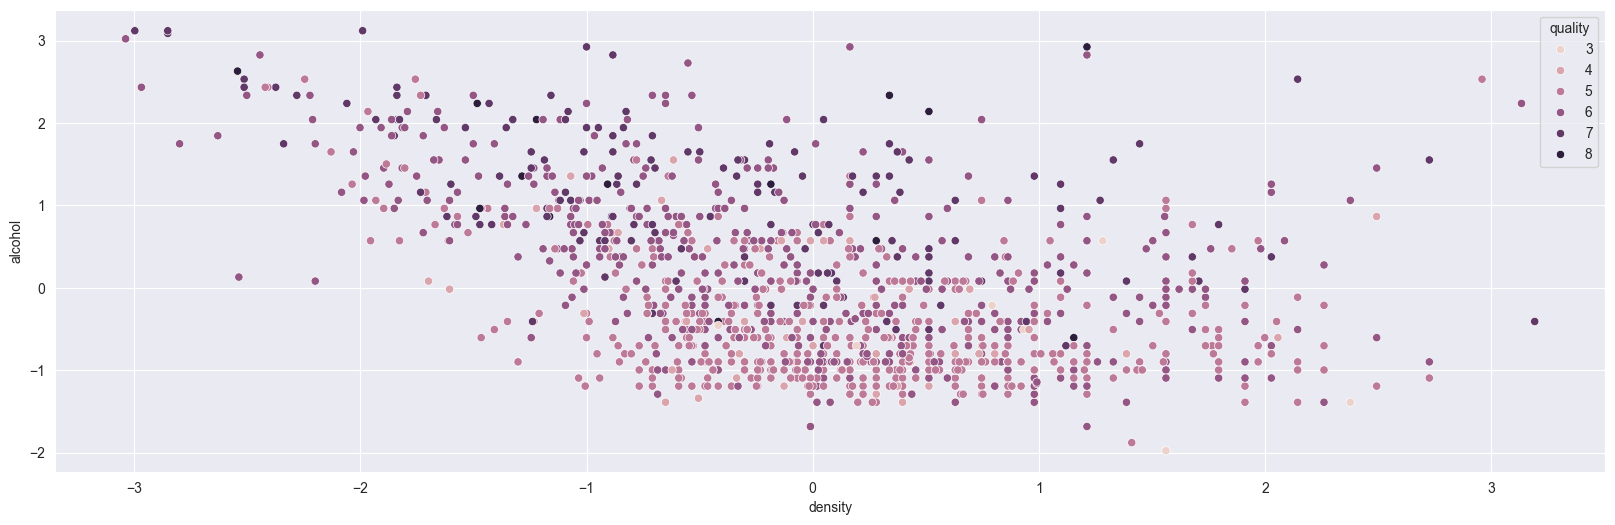

In [411]:
plt.figure(figsize=(20, 6))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

# Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

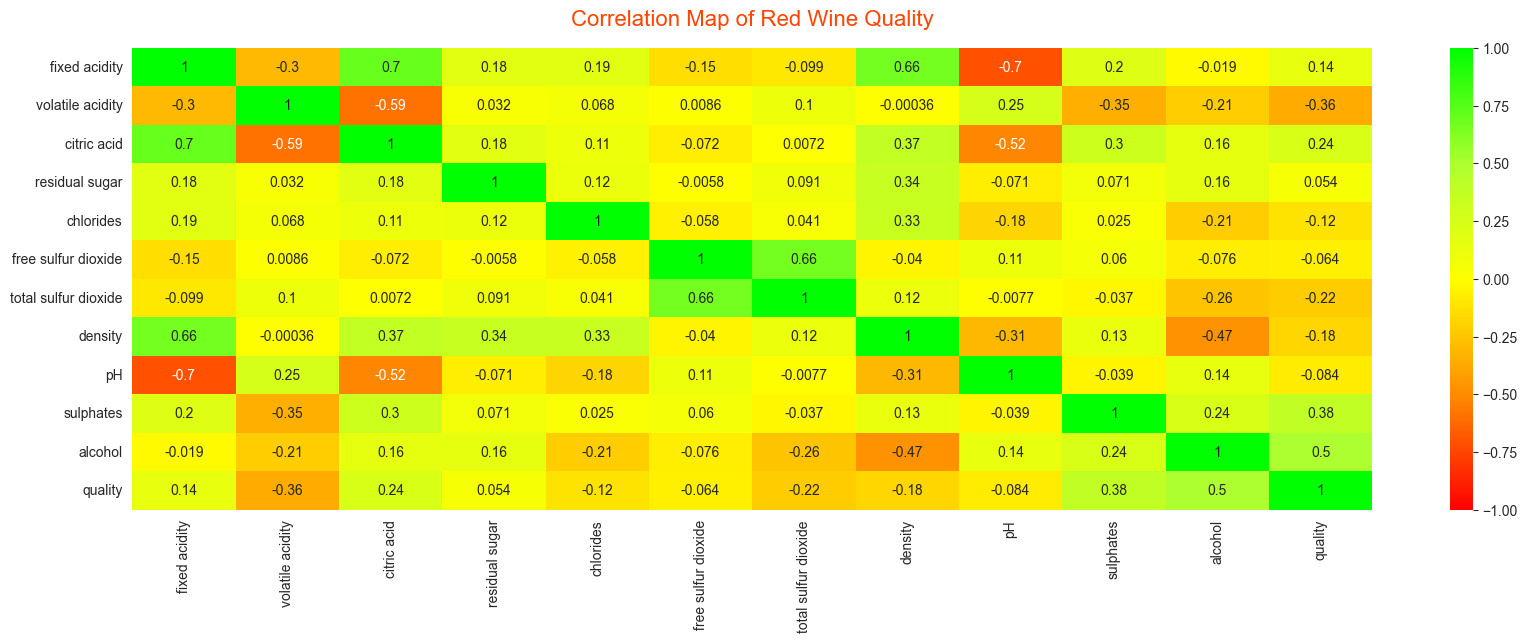

In [412]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# colors
bright_vivid_palette = mcolors.LinearSegmentedColormap.from_list(
    "bright_vivid_colors", ["#FF0000", "#FF8C00", "#FFFF00", "#ADFF2F", "#00FF00"])

plt.figure(figsize=(20, 6))

# colors
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap=bright_vivid_palette, annot_kws={"size": 10})

# titles
plt.title('Correlation Map of Red Wine Quality', fontdict={'fontsize': 16, 'color': '#FF4500'}, pad=16)

# plotting
plt.show()


##### checking the distribution of the data in the quality column

In [413]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

##### as we can see the data is not balanced, so we need to balance it by converting the quality column to binary column

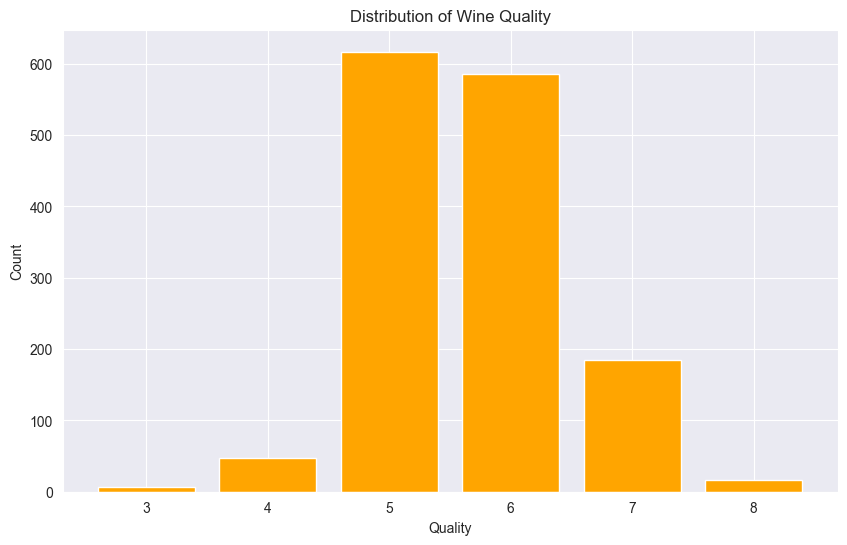

In [414]:
import pandas as pd
import matplotlib.pyplot as plt

quality_counts = redwine_df['quality'].value_counts().sort_index()

quality_df = pd.DataFrame({'quality': quality_counts.index, 'count': quality_counts.values})

# plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(quality_df['quality'], quality_df['count'], color='orange')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.xticks(quality_df['quality'])  # Ensure the x-axis labels match the quality values
plt.show()

- *If the **quality value >= 6**, it means the quality is **good** and I define it as **1**.*
- *If the **quality value < 6,** it means the quality is **bad** and I define it as **0**.*

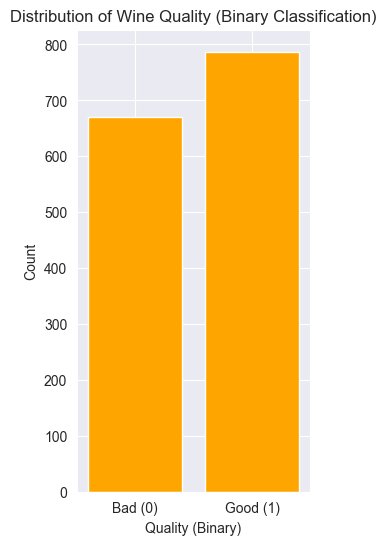

In [415]:
import pandas as pd
import matplotlib.pyplot as plt

# creating a new column for the binary classification named quality_binary
# if the quality value >= 6, it means the quality is good and I define it as 1.
# if the quality value < 6, it means the quality is bad and I define it as 0.
# 0 represents bad quality, 1 represents good quality
redwine_df['quality_binary'] = redwine_df['quality'].apply(lambda x: 0 if x in [3, 4, 5] else 1)

# calculating the value counts of the quality_binary column
quality_binary_counts = redwine_df['quality_binary'].value_counts().sort_index()

# creating a DataFrame from the binary counts
binary_df = pd.DataFrame({'quality_binary': quality_binary_counts.index, 'count': quality_binary_counts.values})

# plotting the bar chart for quality binary (0 = Bad, 1 = Good)
plt.figure(figsize=(3, 6))
plt.bar(binary_df['quality_binary'], binary_df['count'], color='orange')

# lables and title
plt.xticks(binary_df['quality_binary'], labels=['Bad (0)', 'Good (1)'])
plt.xlabel('Quality (Binary)')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality (Binary Classification)')

plt.show()


In [416]:
# dropping the quality column and then renaming the quality_binary column to quality
# now the quality column is the binary column that is going to be used for the binary classification
redwine_df = redwine_df.drop(columns=['quality'], errors='ignore')
redwine_df = redwine_df.rename(columns={'quality_binary': 'quality'})
redwine_df.quality.sample(10)

987     1
879     0
1147    0
851     1
92      0
387     1
174     1
90      0
1100    1
1039    1
Name: quality, dtype: int64

##### checking the corrolation of each column with all the other columns, this pairplot is going to help me to understand the relationship between the columns and the target column.

<Figure size 1400x1000 with 0 Axes>

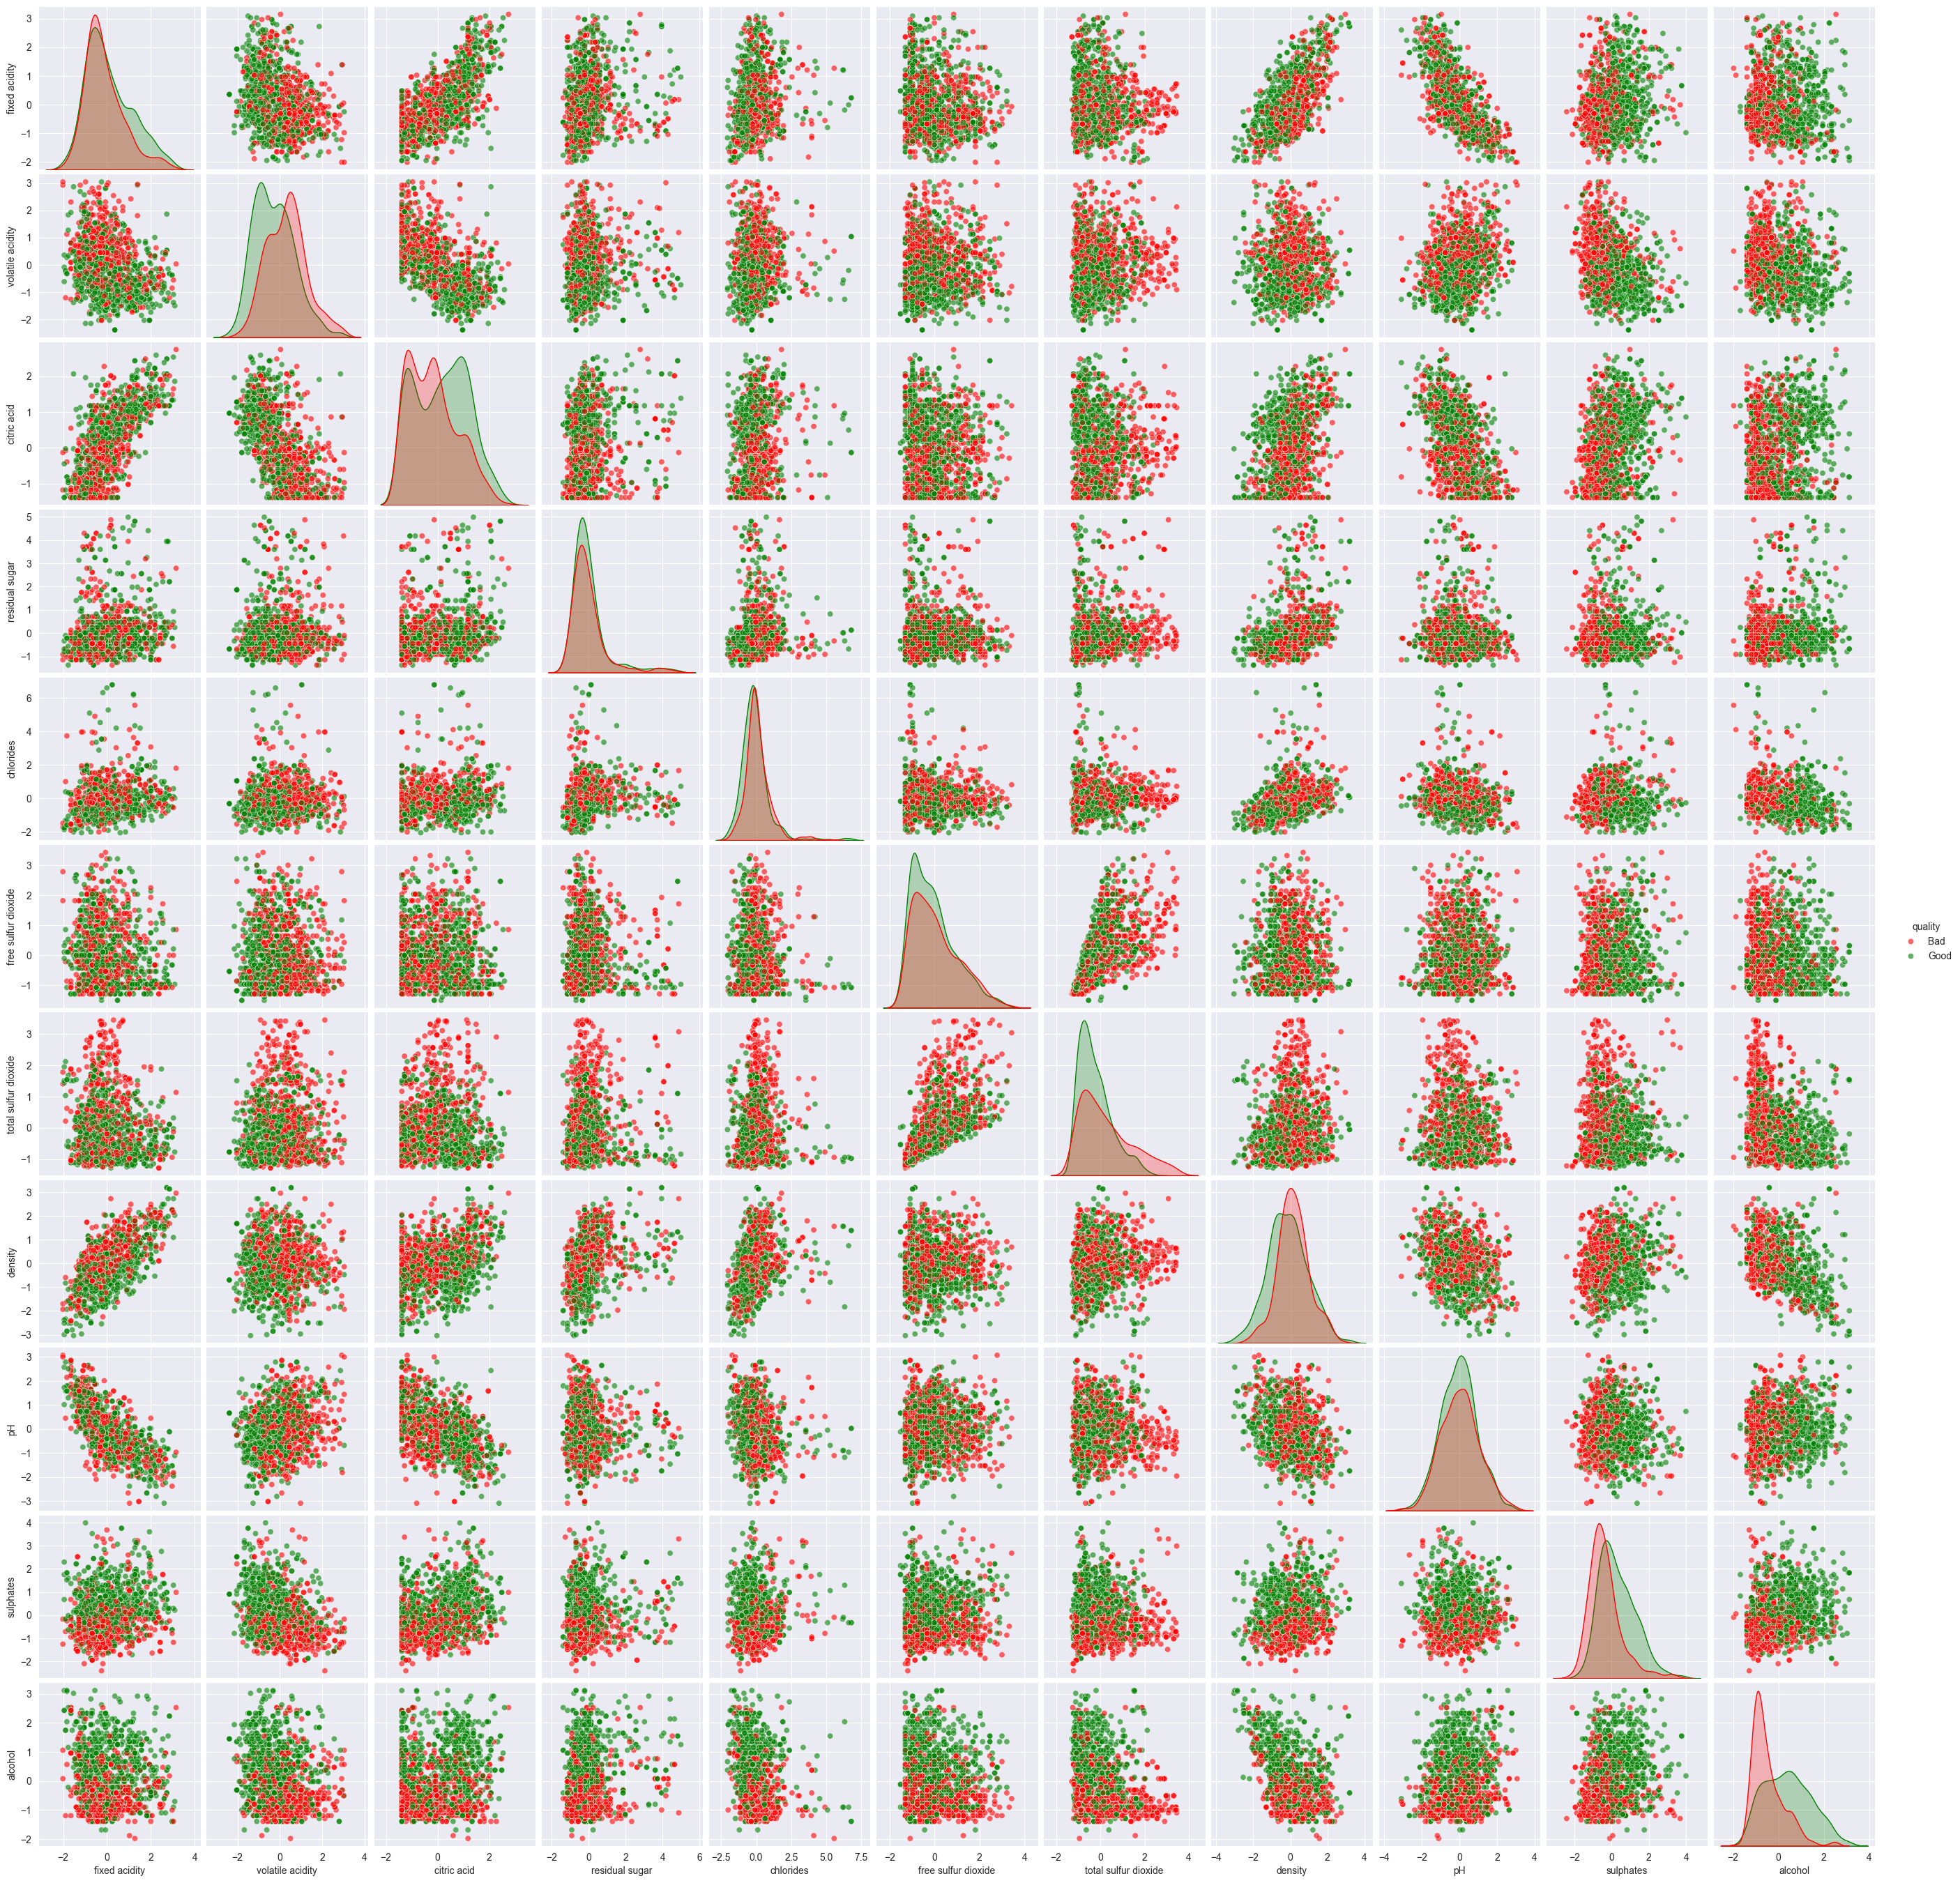

In [417]:
import seaborn as sns
import matplotlib.pyplot as plt

redwine_df['quality'] = redwine_df['quality'].map({0: 'Bad', 1: 'Good'})

# making the pair plot
plt.figure(figsize=(14, 10))
sns.pairplot(redwine_df, hue='quality', palette={'Bad': 'red', 'Good': 'green'}, plot_kws={'alpha':0.6})

# plot
plt.show()


## Find Best K-Score

#### steps
#### 1- splitting the data to train and test
#### 2- finding the best K value. (K value is a value that represents the number of neighbours that the algorithm can take in to account in order to classify )


In [418]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

# Find best K
#### this method is going to identify which K score is the best score for my dataset based on train test splitting of the data.

K = 3: Training Accuracy = 0.8645, Testing Accuracy = 0.7363, Overfitting Score = 0.1282
K = 4: Training Accuracy = 0.8148, Testing Accuracy = 0.7158, Overfitting Score = 0.0990
K = 5: Training Accuracy = 0.8062, Testing Accuracy = 0.7466, Overfitting Score = 0.0596
K = 6: Training Accuracy = 0.7890, Testing Accuracy = 0.7260, Overfitting Score = 0.0630
K = 7: Training Accuracy = 0.7882, Testing Accuracy = 0.7500, Overfitting Score = 0.0382
K = 8: Training Accuracy = 0.7770, Testing Accuracy = 0.7397, Overfitting Score = 0.0373
K = 9: Training Accuracy = 0.7744, Testing Accuracy = 0.7432, Overfitting Score = 0.0313
K = 10: Training Accuracy = 0.7736, Testing Accuracy = 0.7740, Overfitting Score = -0.0004
K = 11: Training Accuracy = 0.7702, Testing Accuracy = 0.7671, Overfitting Score = 0.0030
K = 12: Training Accuracy = 0.7710, Testing Accuracy = 0.7500, Overfitting Score = 0.0210
K = 13: Training Accuracy = 0.7599, Testing Accuracy = 0.7397, Overfitting Score = 0.0201
K = 14: Training

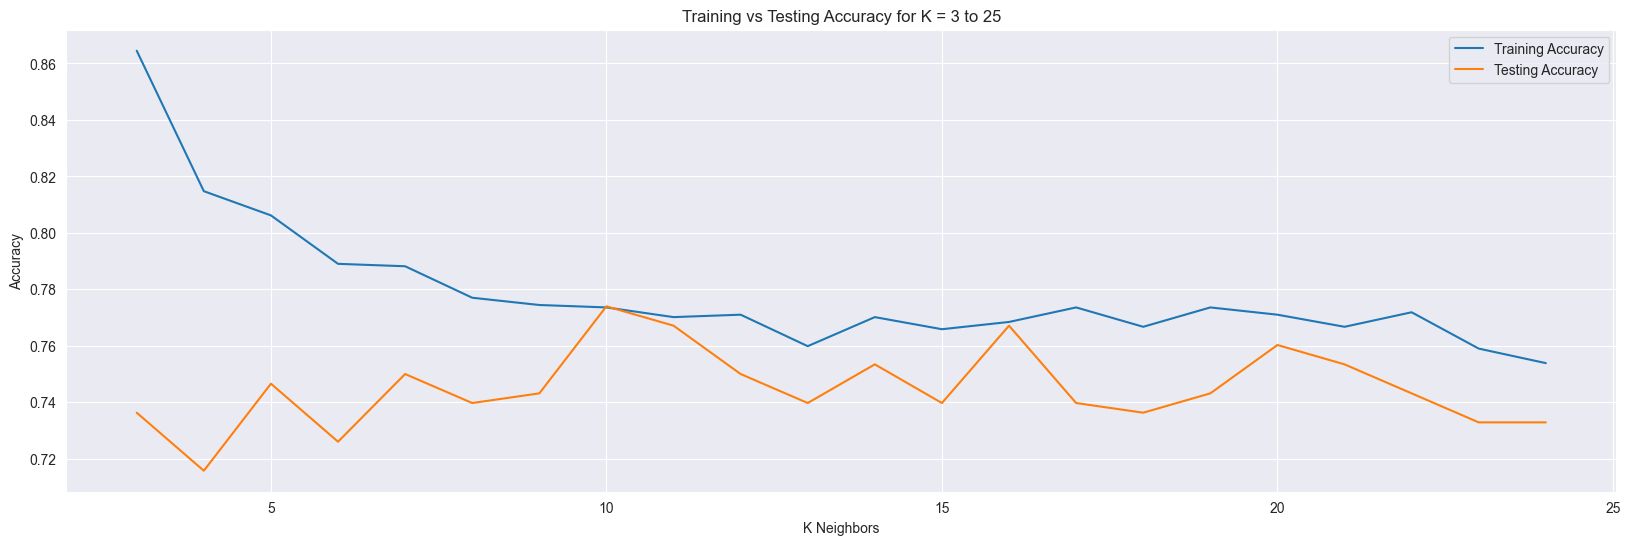

In [419]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Assuming X and y are defined and represent your dataset features and labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Function to find the best K and perform overfitting analysis
def find_best_k(X_train, y_train, X_test, y_test, k_range):
    training_accuracy = []
    testing_accuracy = []
    overfitting_scores = []  # To store the overfitting scores for each K
    best_k = 0
    best_score = 0
    
    k_values = np.arange(k_range[0], k_range[1], k_range[2])

    # Loop over the different K values
    for k in k_values:
        # Define the KNN model with current K value
        knn = KNeighborsClassifier(n_neighbors=k)
        # Create a pipeline with StandardScaler and KNN
        pipeline = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
        
        # Train the model on the training data
        pipeline.fit(X_train, y_train)
        
        # Evaluate on training data
        train_accuracy = pipeline.score(X_train, y_train)
        training_accuracy.append(train_accuracy)
        
        # Evaluate on test data
        test_accuracy = pipeline.score(X_test, y_test)
        testing_accuracy.append(test_accuracy)
        
        # calculating the overfitting score by deducting the test accuracy from the training accuracy
        overfitting_score = train_accuracy - test_accuracy
        overfitting_scores.append(overfitting_score)
        
        # Print the k value, corresponding accuracies, and overfitting score
        print(f"K = {k}: Training Accuracy = {train_accuracy:.4f}, Testing Accuracy = {test_accuracy:.4f}, Overfitting Score = {overfitting_score:.4f}")
        
        # Check if the test accuracy is the best
        if test_accuracy > best_score:
            best_k = k
            best_score = test_accuracy
    
    # checking to see if a certain k value is overfitting or underfitting
    # overfitting happens when the k value is too low and underfitting happens when the k value is too high
    for idx, k in enumerate(k_values):
        if overfitting_scores[idx] > 0.05:  # Threshold for overfitting
            print(f"At K={k}, the model might be overfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        elif overfitting_scores[idx] < -0.05:  # Significant negative score indicating possible underfitting
            print(f"At K={k}, the model might be underfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        else:
            print(f"At K={k}, no significant overfitting or underfitting detected (Overfitting Score: {overfitting_scores[idx]:.4f}).")
    
    return best_k, best_score, training_accuracy, testing_accuracy, k_values

# using the range of k values from 3 to 25 and finding the best k value for the model.
best_k, best_score, training_accuracy, testing_accuracy, k_values = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 25, 1))

# printing the best k value and the best score.
print(f"\nBest K for range 3-25: {best_k}")
print(f"Best Testing Accuracy for range 3-25: {best_score:.4f}")


plt.figure(figsize=(20, 6))
sns.lineplot(x=k_values, y=training_accuracy, label="Training Accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="Testing Accuracy")
plt.title("Training vs Testing Accuracy for K = 3 to 25")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


For \( K = 10 \):
- **Training Accuracy**: 0.7736
- **Testing Accuracy**: 0.7740
- **Overfitting Score**: -0.0004

### Analysis:
1. **Overfitting Score**: The score is **very close to zero** (-0.0004), indicating no significant gap between training and testing accuracies.
2. **Training and Testing Accuracy**: Both accuracies are reasonably high and nearly identical, suggesting the model generalizes well to unseen data.

### Conclusion:
- This model with \( K = 10 \) is **balanced** and exhibits **no significant overfitting or underfitting**.
- The close alignment of training and testing accuracy implies the model is well-suited to the data, making \( K = 10 \) an excellent choice for this scenario.


In [420]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd  # Import pandas for DataFrame

# making the model with 10 neighbors as was measured in the previous step to be the best k value
knn = KNeighborsClassifier(n_neighbors=10)

# creating the pipeline
pipe_knn = Pipeline([('scale', StandardScaler()), ('knn', knn)])

# fitting the model to the training data
pipe_knn.fit(X_train, y_train)

# making predictions on the test set
y_pred = pipe_knn.predict(X_test)

# evaluating the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K=10: {accuracy:.4f}")

print("Classification Report:")
report = classification_report(y_test, y_pred, output_dict=True) 
report_df = pd.DataFrame(report).transpose()

report_df.style.background_gradient(axis=0)


Test Accuracy with K=10: 0.7740
Classification Report:


,precision,recall,f1-score,support
Bad,0.720930,0.756098,0.738095,123.000000
Good,0.815951,0.786982,0.801205,169.000000
accuracy,0.773973,0.773973,0.773973,0.773973
macro avg,0.768441,0.771540,0.769650,292.000000
weighted avg,0.775925,0.773973,0.774621,292.000000


# HyperParameter Tuning

##### checking the parameters of the model and choosing the best parameters for the model

In [421]:
from pprint import pprint
pprint(pipe_knn.get_params(), indent=4)

{   'knn': KNeighborsClassifier(n_neighbors=10),
    'knn__algorithm': 'auto',
    'knn__leaf_size': 30,
    'knn__metric': 'minkowski',
    'knn__metric_params': None,
    'knn__n_jobs': None,
    'knn__n_neighbors': 10,
    'knn__p': 2,
    'knn__weights': 'uniform',
    'memory': None,
    'scale': StandardScaler(),
    'scale__copy': True,
    'scale__with_mean': True,
    'scale__with_std': True,
    'steps': [   ('scale', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=10))],
    'verbose': False}


In [422]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


knn = KNeighborsClassifier()
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', knn)])


param_grid = {
    'knn__n_neighbors': [6, 8, 10, 12, 14, 16, 18],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['manhattan', 'euclidean'],
    'knn__algorithm': ['ball_tree', 'kd_tree', 'brute']
}


grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fitting the grid search on the training data
grid_search.fit(X_train, y_train)

# getting the best parameters and scores
print("Best hyperparameters found: ", grid_search.best_params_)
best_score = grid_search.best_score_
print(f"Best accuracy score from GridSearchCV: {best_score:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Test Accuracy after Hyperparameter Tuning: {accuracy_score(y_test, y_pred_best):.4f}")
print("Classification Report for Best Model:")

report = classification_report(y_test, y_pred_best, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.style.background_gradient(axis=0)

Best hyperparameters found:  {'knn__algorithm': 'ball_tree', 'knn__metric': 'manhattan', 'knn__n_neighbors': 16, 'knn__weights': 'distance'}
Best accuracy score from GridSearchCV: 0.8002
Test Accuracy after Hyperparameter Tuning: 0.8185
Classification Report for Best Model:


,precision,recall,f1-score,support
Bad,0.782258,0.788618,0.785425,123.000000
Good,0.845238,0.840237,0.842730,169.000000
accuracy,0.818493,0.818493,0.818493,0.818493
macro avg,0.813748,0.814427,0.814078,292.000000
weighted avg,0.818709,0.818493,0.818591,292.000000


In [423]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# the KNN model with the best parameters from GridSearchCV and StandardScaler
knn_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        algorithm='ball_tree',
        metric='manhattan',
        n_neighbors=16,
        weights='distance'    ))
])

# Fit the model with the tuned hyperparameters on the training data
knn_tuned.fit(X_train, y_train)

# predictions on the test set
y_pred = knn_tuned.predict(X_test)

# evaluating the tuned model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy of tuned KNN model: {accuracy:.4f}")


Testing Accuracy of tuned KNN model: 0.8185
